# Student GPA Prediction

## Business Problem
Understanding what drives student academic performance helps schools and parents intervene early — before a student falls behind. This project builds a regression model to predict a student's GPA based on academic habits, parental involvement, and extracurricular activity.

## Dataset
The dataset contains student-level records including demographics (Age, Gender, Ethnicity), academic behavior (StudyTimeWeekly, Absences, Tutoring), parental factors (ParentalEducation, ParentalSupport), and extracurricular involvement (Sports, Music, Volunteering, Extracurricular), alongside the target variable **GPA**.

## Goal
- Explore the relationships between student attributes and GPA.
- Select meaningful features while avoiding data leakage.
- Train and evaluate a regression model that generalizes well (no overfitting).
- Compare against alternative models to validate the choice of approach.

## Importing Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

## Read the data
[Date set link](https://www.kaggle.com/datasets/rabieelkharoua/students-performance-dataset?utm_source=chatgpt.com)

In [35]:
df = pd.read_csv ("./data/data.csv")

In [36]:
print (df.shape)
num_of_actual_rows = df.shape [0]
df.head ()

(2392, 15)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


## Understanding and exploring data

In [37]:
df.info ()

<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [38]:
# Drop useless columns
df.drop (columns= ["StudentID"], inplace= True)

In [39]:
df.describe ()

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


## Data Preprocessing

In [40]:
df.isnull ().sum ()

Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [41]:
df.duplicated ().sum ()

np.int64(0)

In [42]:
# we will predict GPA so we need to remove GradeClass. Because GradeClass is derived from GPA, it will cause data leakage if we keep it in the model.
df.drop (columns= ["GradeClass"], inplace= True)


all_col = df.columns
num_cols = ['Age', 'StudyTimeWeekly', 'Absences']
binary_cols = ['Gender', 'Tutoring', 'Extracurricular', 'Sports', 'Music', 'Volunteering']

nominal_cols = ['Ethnicity']

ordinal_cols = ['ParentalEducation', 'ParentalSupport']

target = 'GPA'

## Visualization and Feature Understanding

### Numerical Features

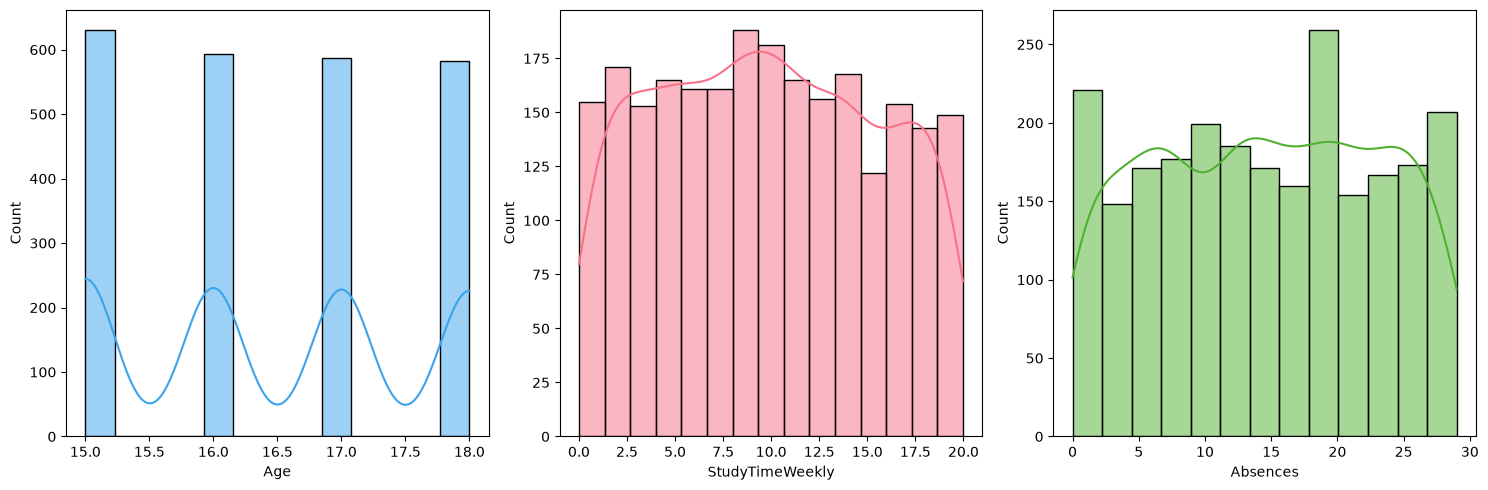

In [43]:
palette = sns.color_palette("husl", len(num_cols))

n = len (num_cols)
COLUMNS = 3
rows = math.ceil (n / COLUMNS)

fig, axes = plt.subplots (rows, COLUMNS, figsize= (15, 5 * rows))
axes = axes.flatten ()

for i, col in enumerate (num_cols):
    sns.histplot (df [col], kde= True, ax= axes [i], color=palette[i-1])
    # axes [i].set_title (col)

for j in range (i + 1, len (axes)):
    fig.delaxes (axes [j])

plt.tight_layout ()
plt.show ()

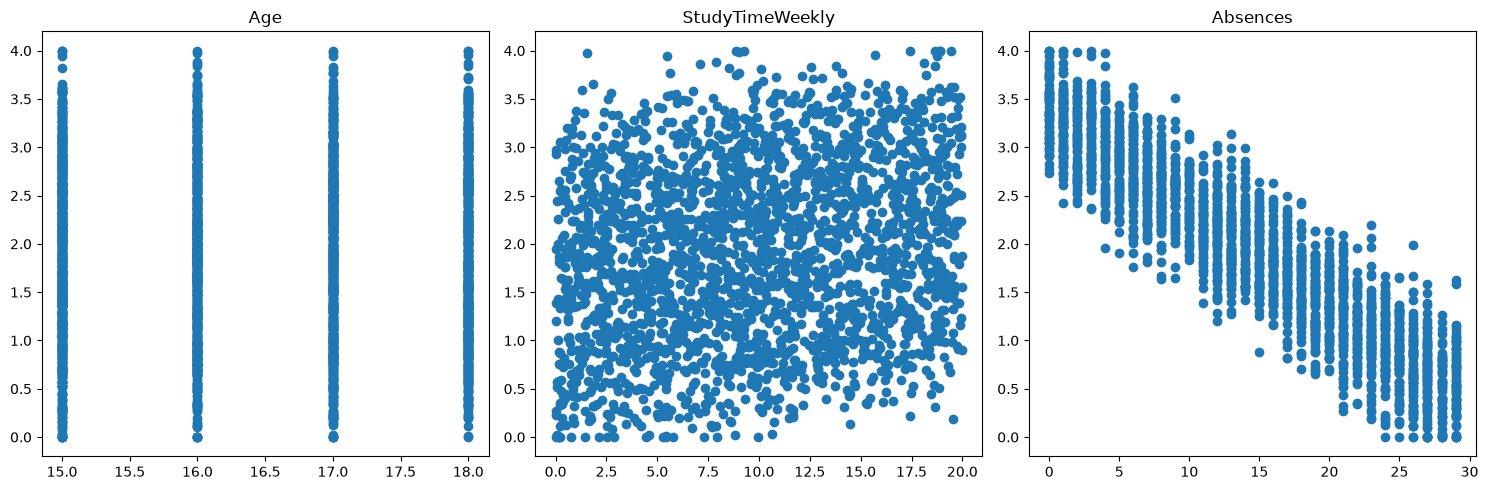

In [44]:
n = len (num_cols)
COLUMNS = 3
rows = math.ceil (n / COLUMNS)

fig, axes = plt.subplots (rows, COLUMNS, figsize= (15, 5 * rows))
axes = axes.flatten ()

for i, col in enumerate (num_cols):
    axes [i].scatter (df [col], df [target])
    axes [i].set_title (col)

for j in range (i + 1, len (axes)):
    fig.delaxes (axes [j])

plt.tight_layout ()
plt.show ()

In [45]:
correlations = df[num_cols + [target]].corr()
correlations

,Age,StudyTimeWeekly,Absences,GPA
Age,1.000000,-0.006800,-0.011511,0.000275
StudyTimeWeekly,-0.006800,1.000000,0.009326,0.179275
Absences,-0.011511,0.009326,1.000000,-0.919314
GPA,0.000275,0.179275,-0.919314,1.000000


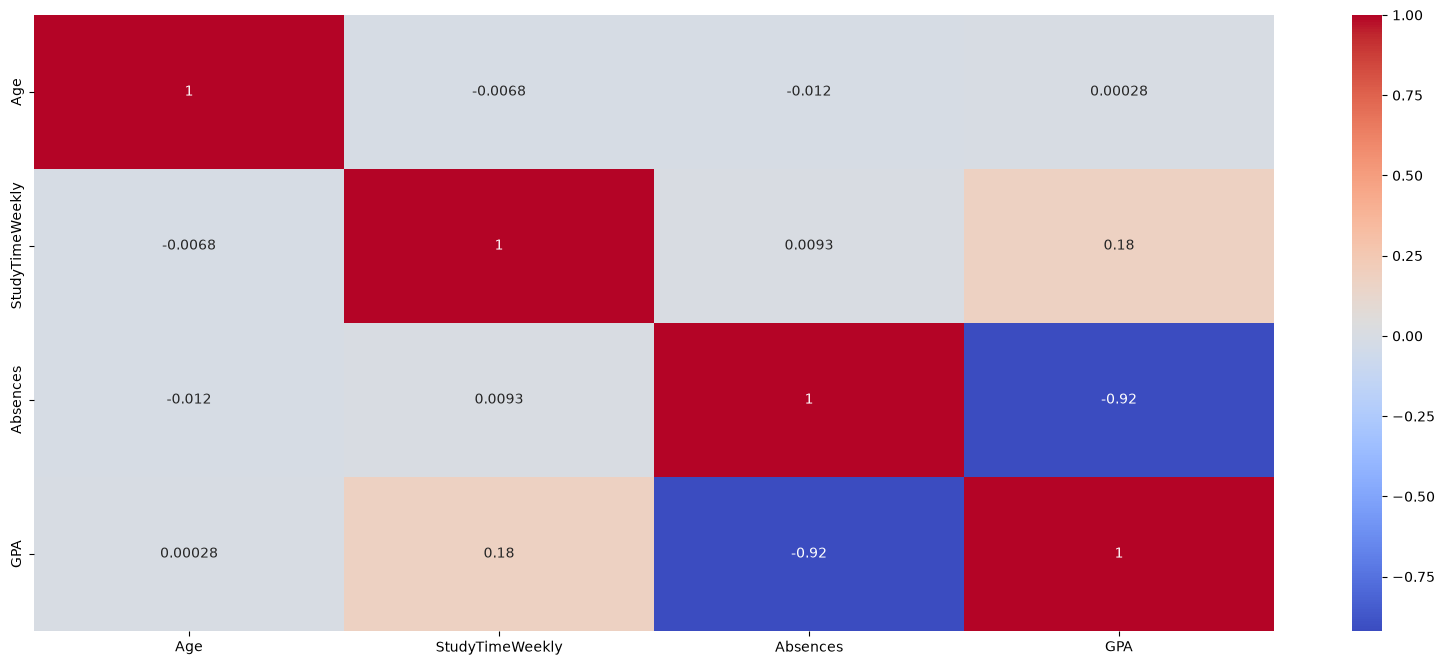

In [46]:
plt.figure (figsize= (20, 8))
sns.heatmap (correlations, annot= True, cmap= "coolwarm")
plt.show ()

### select features from numerical cols

In [47]:
features = ['StudyTimeWeekly', 'Absences']

## Categorical Features

In [48]:
print (binary_cols)

['Gender', 'Tutoring', 'Extracurricular', 'Sports', 'Music', 'Volunteering']


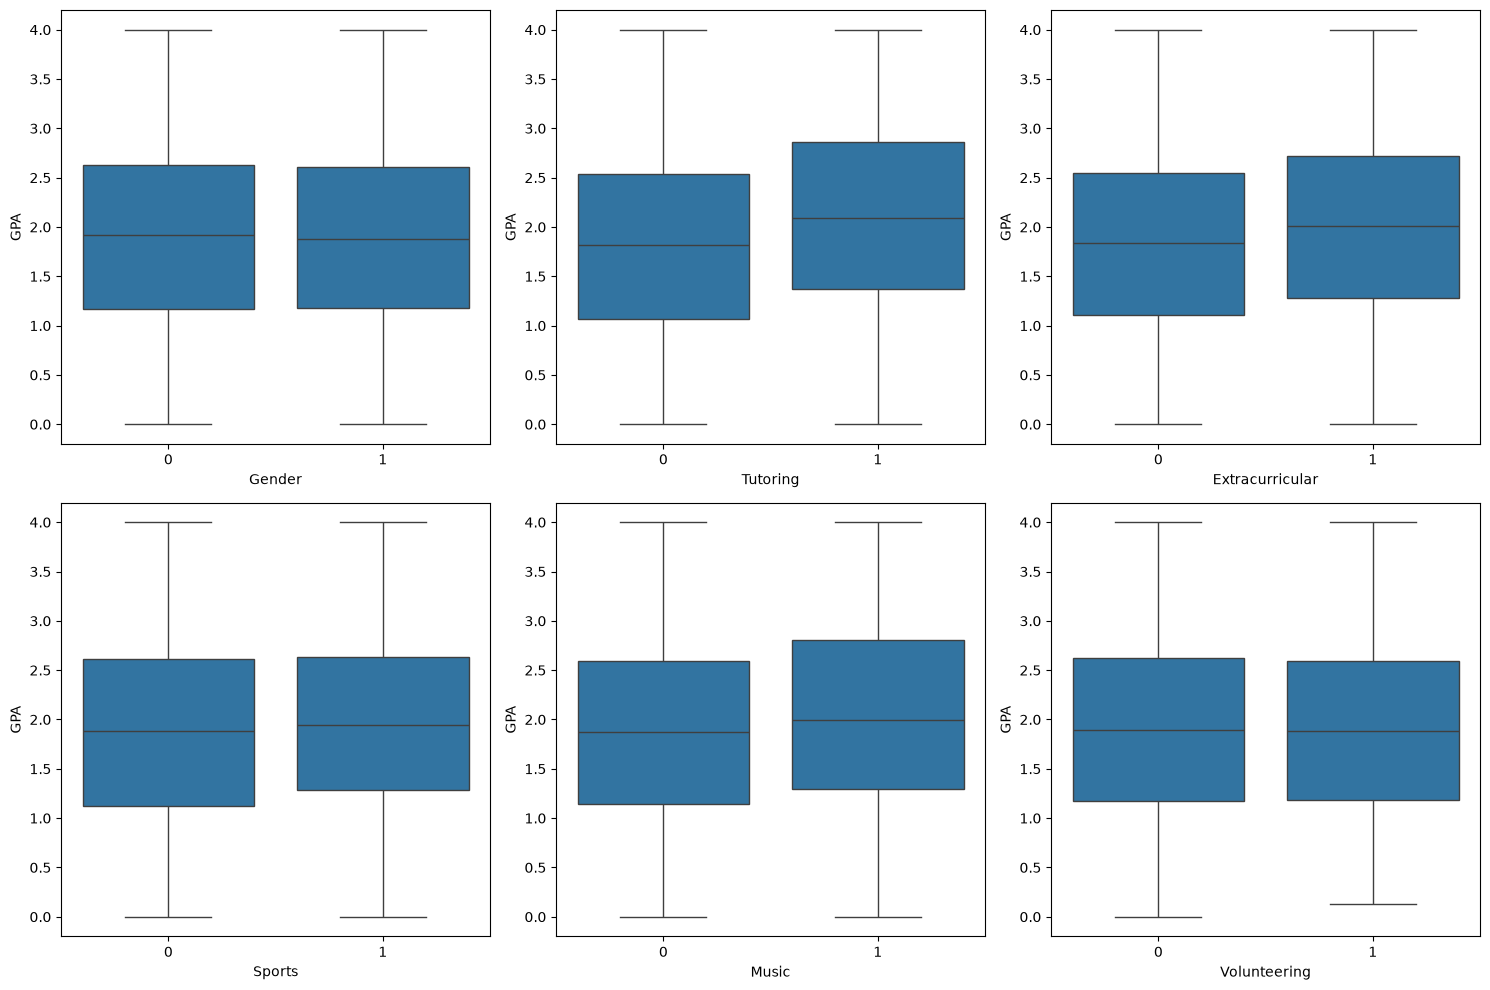

In [49]:
n = len (binary_cols)
COLUMNS = 3
rows = math.ceil (n / COLUMNS)

fig, axes = plt.subplots (rows, COLUMNS, figsize= (15, 5 * rows))
axes = axes.flatten ()

for i, col in enumerate (binary_cols):
    sns.boxplot (x= df [col], y= df ["GPA"], ax= axes [i])
    # axes [i].set_title (col)

for j in range (i + 1, len (axes)):
    fig.delaxes (axes [j])

plt.tight_layout ()
plt.show ()

In [50]:
features.extend (['Tutoring', 'Extracurricular', 'Sports', 'Music'])
print (features)

['StudyTimeWeekly', 'Absences', 'Tutoring', 'Extracurricular', 'Sports', 'Music']


## Nominal Features

In [51]:
print (nominal_cols)

['Ethnicity']


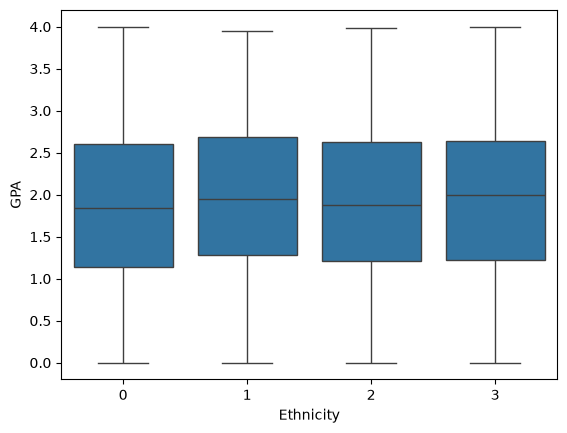

In [52]:
sns.boxplot (x= df ['Ethnicity'], y= df ["GPA"])
plt.show ()

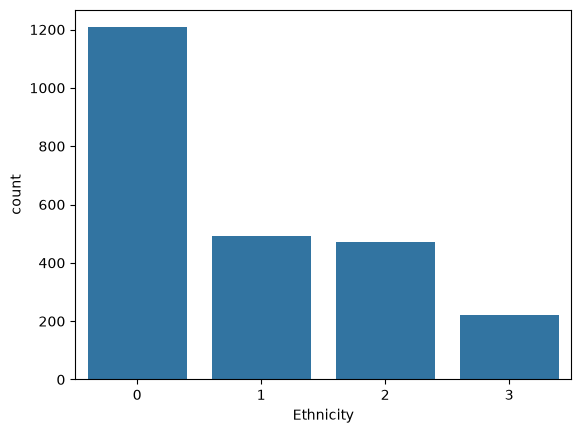

In [53]:
sns.countplot (data=df, x='Ethnicity')
plt.show ()

## Ordinal Features

In [54]:
ordinal_cols

['ParentalEducation', 'ParentalSupport']

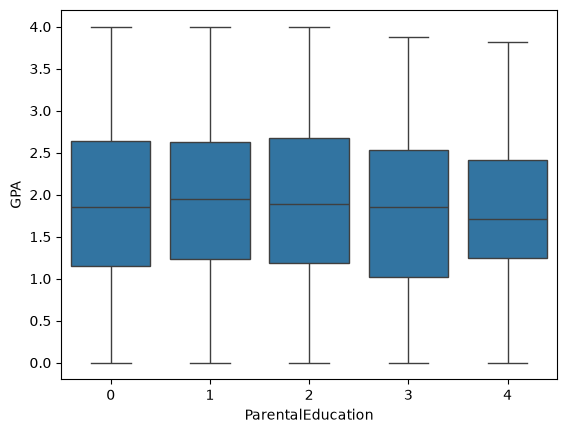

In [55]:
sns.boxplot (data=df, x='ParentalEducation', y='GPA')
plt.show ()

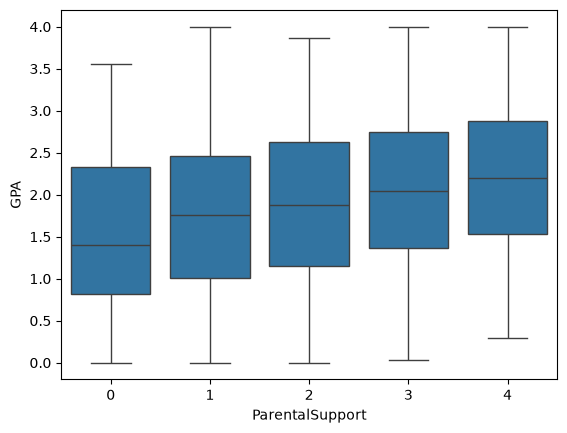

In [56]:
sns.boxplot (data=df, x='ParentalSupport', y='GPA')
plt.show ()

In [57]:
features.append ('ParentalSupport')
print (features)

['StudyTimeWeekly', 'Absences', 'Tutoring', 'Extracurricular', 'Sports', 'Music', 'ParentalSupport']


## Model 🤖

In [58]:
X = df [features] # Features
Y = df ["GPA"]  # Target

### Train / Test split

In [59]:
x_train, x_test, y_train, y_test = train_test_split (
    X, Y,
    test_size= 0.2,
    random_state= 42
)

### Selecting the model and training it

In [60]:
model = LinearRegression ()
model.fit (x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 0.03,-0.1 , 0.26,..., 0.19, 0.15, 0.15]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['StudyTimeWeekly','Absences','Tutoring',...,'Sports','Music', 'ParentalSupport']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.519
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [61]:
y_pred = model.predict (x_test)

In [62]:
mae = mean_absolute_error (y_test, y_pred)
print ("MAE:", mae)

MAE: 0.1555593752850386


In [63]:
r2_score (y_test, y_pred)

0.9531135453025407

In [64]:
# Predictions
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt (mean_squared_error (y_train, y_train_pred))
test_rmse = np.sqrt (mean_squared_error (y_test, y_test_pred))

print(f"Train R²: {train_r2:.4f}   |   Test R²: {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}   |   Test RMSE: {test_rmse:.4f}")

# Simple overfitting check
gap = train_r2 - test_r2
if gap > 0.1:
    print(f"⚠️ Possible overfitting — R² gap = {gap:.4f}")
else:
    print(f"✅ No strong sign of overfitting — R² gap = {gap:.4f}")

Train R²: 0.9540   |   Test R²: 0.9531
Train RMSE: 0.1964   |   Test RMSE: 0.1969
✅ No strong sign of overfitting — R² gap = 0.0009


In [65]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Dictionary to store models and results
models = {
    'LinearRegression': model,
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(C=100)
}

# Train and evaluate each model
results = []

for name, model_obj in models.items():
    # Train the model
    model_obj.fit(x_train, y_train)
    
    # Make predictions
    y_train_pred = model_obj.predict(x_train)
    y_test_pred = model_obj.predict(x_test)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    results.append({
        'Model': name,
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train MAE': train_mae,
        'Test MAE': test_mae
    })

# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test R²', ascending=False).reset_index(drop=True)
results_df['Rank'] = range(1, len(results_df) + 1)

print(results_df)

              Model  Train R²   Test R²  Train RMSE  Test RMSE  Train MAE  \
0             Ridge  0.954035  0.953120    0.196449   0.196892   0.159207   
1  LinearRegression  0.954035  0.953114    0.196448   0.196906   0.159205   
2               SVR  0.956179  0.951465    0.191811   0.200337   0.153792   
3  GradientBoosting  0.960827  0.946543    0.181354   0.210251   0.145053   
4      RandomForest  0.990681  0.930388    0.088453   0.239926   0.070518   
5               KNN  0.944600  0.920491    0.215670   0.256415   0.173581   
6      DecisionTree  1.000000  0.883786    0.000000   0.310002   0.000000   
7        ElasticNet  0.866748  0.864588    0.334481   0.334629   0.269855   
8             Lasso  0.828045  0.830248    0.379963   0.374664   0.306383   

   Test MAE  Rank  
0  0.155537     1  
1  0.155559     2  
2  0.158257     3  
3  0.163216     4  
4  0.187327     5  
5  0.203877     6  
6  0.244645     7  
7  0.270012     8  
8  0.302872     9  


## Conclusion

- **Data leakage handled:** `GradeClass` was dropped early, since it is directly derived from GPA and would have artificially inflated model performance.
- **Feature selection:** Features were chosen using a combination of visual inspection (histograms, boxplots, correlation heatmap) and statistical scoring (`SelectKBest`), then validated by testing their actual impact on model performance.
- **Best model:** `LinearRegression` with 7 features (`StudyTimeWeekly`, `Absences`, `Tutoring`, `Extracurricular`, `Sports`, `Music`, `ParentalSupport`) achieved:
  - **Test R²:** 0.9531
  - **Test RMSE:** 0.1969
  - **Train/Test R² gap:** 0.0009 → no signs of overfitting
- **Model comparison:** Regularized linear models (Ridge, Lasso, ElasticNet) performed identically to plain Linear Regression, and more complex models (Random Forest, Gradient Boosting, SVR, Decision Tree) did **not** outperform it — suggesting the underlying relationship between features and GPA is largely linear.
- **Most influential features:** `Absences` and `ParentalSupport` showed the strongest individual relationship with GPA, though all 7 selected features contributed to the model's final performance.

**Takeaway:** A simple, interpretable Linear Regression model is sufficient and optimal for this dataset — added model complexity provides no measurable benefit.